,N,M,W_mean,W_std
0,2500,10,0.320800,0.005028
1,3000,10,0.299167,0.006970
2,3500,10,0.285057,0.004879
3,4000,10,0.270650,0.006525
4,4500,10,0.256622,0.004890
5,5000,10,0.247540,0.005034


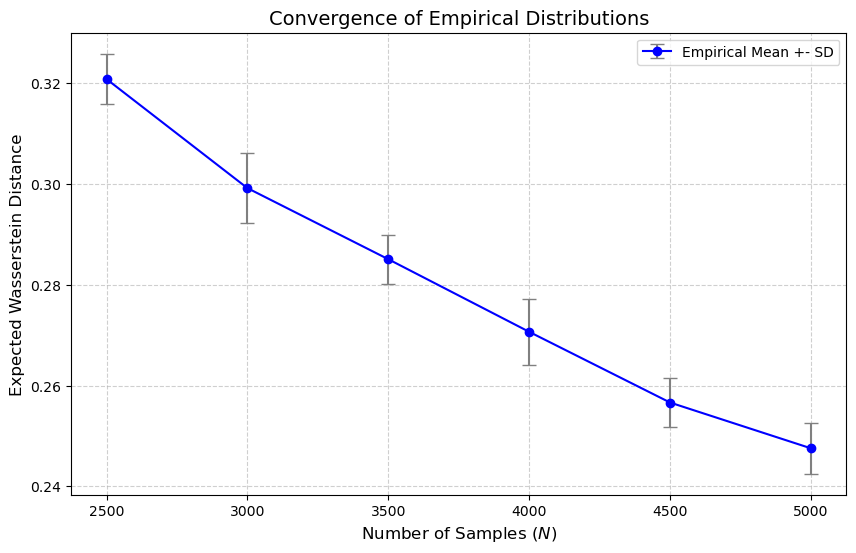

In [31]:
from utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from ripser import ripser
from tqdm import tqdm
from joblib import Parallel, delayed

from IPython.display import display, clear_output

from scipy.optimize import linear_sum_assignment # to solve the optimal transport problem.

# template raster
# by loop we mean neurons will fire in a sequence looping back: 1->2->3...->12->1
def make_loop_template(n_neurons=12, T=500, arc_width=80):
    raster = np.zeros((n_neurons, T), dtype=int) #initial raster with zeros
    centers = np.linspace(0, T, n_neurons, endpoint=False).astype(int) # for each neuron pick a center equally spread.
    half = arc_width // 2 # we'll ensure that spikes overlap
    for i, c in enumerate(centers): # neuron i, center c
        idx = (np.arange(c - half, c + half) % T).astype(int) # spike times of neuron i. Modulo T ensures a spike at time say 495ms wraps around to 5ms.
        raster[i, idx] = 1 
    return raster

# function to build trials from a given template raster.
def generate_trials(template, n_trials=30, random_state=42, permute=False):
    """Generates noisy trials from a given template raster."""
    rng = np.random.default_rng(random_state)
    n_neurons, T = template.shape
    trials = []
    for _ in range(n_trials):
        noisy = add_noise_to_raster(template, random_state=rng) # this is noisy raster generated from the template.
        
        shifted = np.roll(noisy, rng.integers(0, T), axis=1) # we will process this again by shifting all spikes by a random integer specified by rng.integers(0, T)
        # this will ensure same topological pattern but at distinct times.

        if permute:
            trials.append(shifted[rng.permutation(n_neurons), :]) # optionally we can permute the neuron labels too. Topology will remain the same.
        else:
            trials.append(shifted)
            
    return np.array(trials)


def rasters_to_barcode(list_of_rasters, dim=0):
    list_of_barcodes = []
    calc_dim = max(dim, 1) 
    for raster in tqdm(list_of_rasters, desc=f"Generating barcodes (dim={dim})", leave=False):
        vp_dm = VP_trivial(raster)
        dgm = ripser(vp_dm, distance_matrix=True, maxdim=calc_dim)['dgms'][dim]
        list_of_barcodes.append(dgm)
    return list_of_barcodes


# think two probability measures on the space of barcodes with bottleneck distance.
# following function will compute 1-Wasserstein distance (Earth-Movers distance) between those prob. measures.
# based on a cost-matrix which is pairwise bottleneck distance matrix given two sets of barcodes.
def compute_empirical_wasserstein_parallel(barcodes1, barcodes2, n_jobs=-1):
    """Computes 1-Wasserstein distance using parallel bottleneck calculations."""
    N = len(barcodes1)
    # Parallelize N*N bottleneck computations
    flat_costs = Parallel(n_jobs=n_jobs)(
        delayed(bottleneck_zero)(barcodes1[i], barcodes2[j])
        for i in range(N) for j in range(N)
    )
    cost_matrix = np.array(flat_costs).reshape(N, N)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return cost_matrix[row_ind, col_ind].mean()

def get_adaptive_M(N):
    """Adaptive M logic as requested for publication scaling."""
    if N <= 50: return 100
    if N <= 100: return 50
    if N <= 300: return 25
    if N <= 500: return 20
    if N <= 1500: return 15
    return 10

def run_stability_experiment(N_values, csv_name="stability_results.csv"):
    template = make_loop_template()
    results_df = pd.DataFrame(columns=['N', 'M', 'W_mean', 'W_std'])
    
    # Initialize CSV if it doesn't exist
    if not os.path.exists(csv_name):
        results_df.to_csv(csv_name, index=False)

    print(f"Starting Stability Experiment. Results saved to {csv_name}")

    for N in N_values:
        M = get_adaptive_M(N)
        w_dists = []
        
        # tqdm for outer repetition monitoring
        for m in tqdm(range(M), desc=f"N={N}, M={M}", leave=False):
            # Step 3: Draw N samples twice 
            trials_1 = generate_trials(template, n_trials=N,random_state = None)
            trials_2 = generate_trials(template, n_trials=N,random_state = None)
            
            # Map samples to barcodes (parallelization here is handled in W-dist)
            barcodes_1 = [ripser(VP_trivial(r), distance_matrix=True)['dgms'][0] for r in trials_1]
            barcodes_2 = [ripser(VP_trivial(r), distance_matrix=True)['dgms'][0] for r in trials_2]
            
            w = compute_empirical_wasserstein_parallel(barcodes_1, barcodes_2)
            w_dists.append(w)
            
        # Step 4: Aggregate results
        new_row = {
            'N': N,
            'M': M,
            'W_mean': np.mean(w_dists),
            'W_std': np.std(w_dists)
        }
        
        # Save to CSV immediately
        temp_df = pd.DataFrame([new_row])
        temp_df.to_csv(csv_name, mode='a', header=False, index=False)
        results_df = pd.concat([results_df, temp_df], ignore_index=True)
        
        # Display current status
        clear_output(wait=True)
        display(results_df)

    return results_df



if __name__ == "__main__":
    # Ns = [10, 20, 30, 40, 50, 100, 200, 300, 400, 500, 1000, 1500, 2000] 
    Ns = [2500,3000,3500,4000,4500,5000] 
    final_results = run_stability_experiment(Ns)


    plt.figure(figsize=(10, 6))
    plt.errorbar(final_results['N'], final_results['W_mean'], 
                 yerr=final_results['W_std'], fmt='o-', capsize=5, 
                 color='blue', ecolor='gray', label='Empirical Mean +- SD')
    
    plt.xlabel('Number of Samples ($N$)', fontsize=12)
    plt.ylabel('Expected Wasserstein Distance', fontsize=12)
    plt.title('Convergence of Empirical Distributions', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.savefig('empirical_convergence_v2.pdf',bbox_inches = 'tight')
    plt.show()

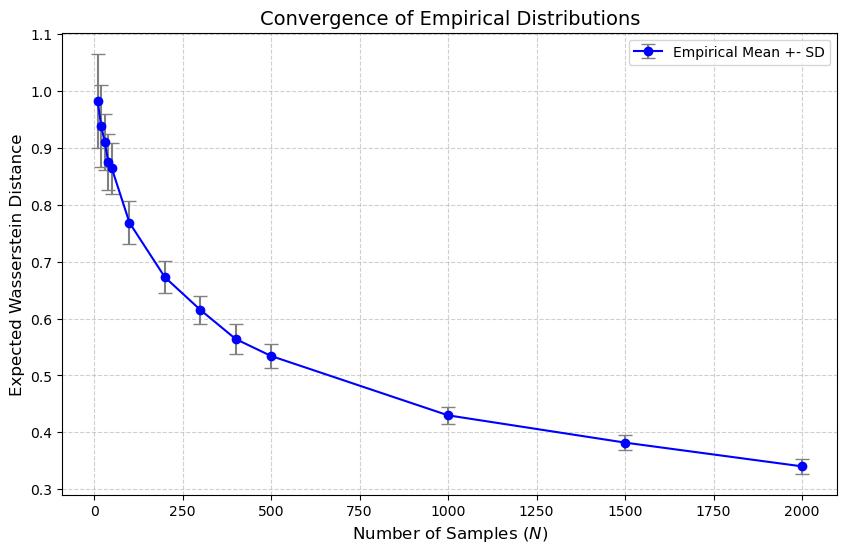

In [30]:
plt.figure(figsize=(10, 6))
plt.errorbar(final_results['N'], final_results['W_mean'], 
                yerr=final_results['W_std'], fmt='o-', capsize=5, 
                color='blue', ecolor='gray', label='Empirical Mean +- SD')

plt.xlabel('Number of Samples ($N$)', fontsize=12)
plt.ylabel('Expected Wasserstein Distance', fontsize=12)
plt.title('Convergence of Empirical Distributions', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('empirical_convergence_v1.pdf',bbox_inches = 'tight')
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
combined_results = pd.read_csv('stability_results.csv')

In [2]:
combined_results

,N,M,W_mean,W_std
0,10,100,0.983000,0.082529
1,20,100,0.938500,0.072407
2,30,100,0.910667,0.048735
3,40,100,0.874750,0.049560
4,50,100,0.864200,0.044926
5,100,50,0.768400,0.038176
6,200,25,0.672600,0.027969
7,300,25,0.615333,0.024801
8,400,20,0.564000,0.026237
9,500,20,0.534200,0.020277


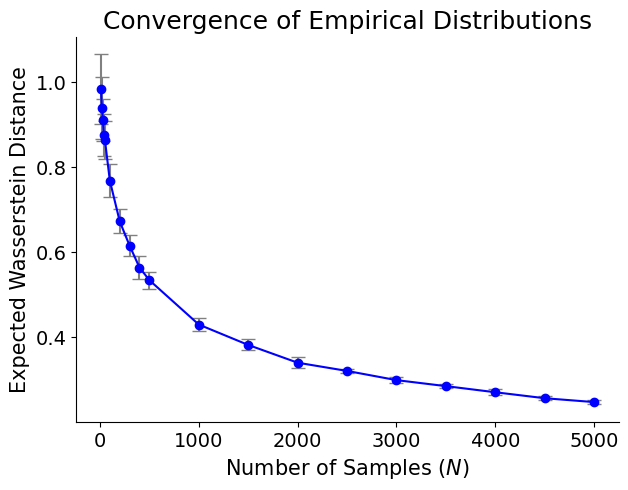

In [29]:
import matplotlib.pyplot as plt
# ---- font controls ----
legend_font_size = 14
font_size = 30
axes_titlesize = 18
axes_labelsize = 15
xtick_labelsize = 14
ytick_labelsize = 14
figure_titlesize = 20

# y_ticks = [0.25,0.5,0.75,1.0]

plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": axes_titlesize,
    "axes.labelsize": axes_labelsize,
    "xtick.labelsize": xtick_labelsize,
    "ytick.labelsize": ytick_labelsize,
    "legend.fontsize": legend_font_size,
    "figure.titlesize": figure_titlesize,
})


plt.figure(figsize=(7, 5))
plt.errorbar(combined_results['N'], combined_results['W_mean'], 
                yerr=combined_results['W_std'], fmt='o-', capsize=5, 
                color='blue', ecolor='gray', label='Empirical Mean +- SD')

plt.xlabel('Number of Samples ($N$)')
plt.ylabel('Expected Wasserstein Distance')
plt.title('Convergence of Empirical Distributions')
# plt.grid(True, linestyle='--', alpha=0.6)



# Get the current axes (gca)
ax = plt.gca()

# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.legend()
plt.savefig('empirical_convergence_v2.pdf',bbox_inches = 'tight')
plt.show()